In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

# ========================
# Configuración de rutas
# ========================
DATA_DIR = Path(r"E:\USUARIO\Desktop\Dataset 5")
CSV_FLOWS = DATA_DIR / "Dataset.csv"
CSV_ATTACKS = DATA_DIR / "attacker_machine_summary.csv"

# Semilla global para reproducibilidad (la fijamos aquí para que quede documentado)
SEED = 42
np.random.seed(SEED)

print(f"Rutas configuradas:")
print(f"  Flujos:  {CSV_FLOWS}")
print(f"  Ataques: {CSV_ATTACKS}")
print(f"  Existen: {CSV_FLOWS.exists()} / {CSV_ATTACKS.exists()}")

Rutas configuradas:
  Flujos:  E:\USUARIO\Desktop\Dataset 5\Dataset.csv
  Ataques: E:\USUARIO\Desktop\Dataset 5\attacker_machine_summary.csv
  Existen: True / True


Forma del dataset: (45718, 64)
Número de filas (flujos): 45,718
Número de columnas: 64

Metadatos:           13 columnas
Features numéricas:  47 columnas
Etiquetas:           4 columnas
Total verificado:    64 columnas

Primeras columnas con sus tipos:
sAddress      object
rAddress      object
sMACs         object
rMACs         object
sIPs          object
rIPs          object
protocol      object
startDate     object
endDate       object
start        float64
dtype: object


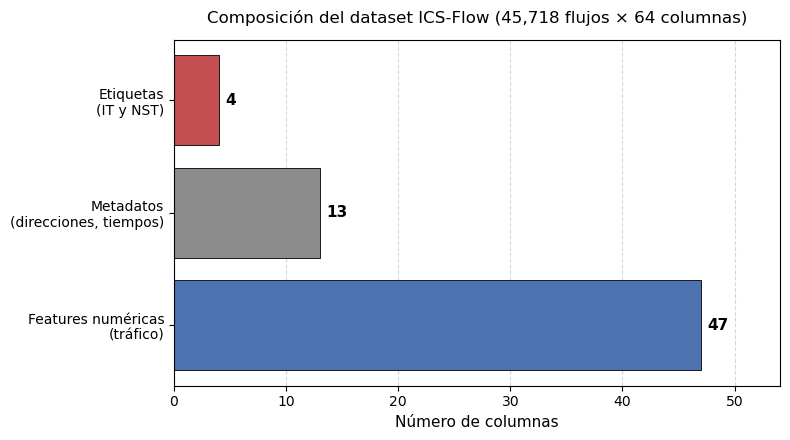

In [8]:
# Carga del CSV principal
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_FLOWS)
print(f"Forma del dataset: {df.shape}")
print(f"Número de filas (flujos): {len(df):,}")
print(f"Número de columnas: {df.shape[1]}")
print()

# Clasificación de columnas según los tres grupos descritos en la memoria
metadata_cols = ['sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs',
                 'protocol', 'startDate', 'endDate', 'start', 'end',
                 'startOffset', 'endOffset']
label_cols = ['IT_B_Label', 'IT_M_Label', 'NST_B_Label', 'NST_M_Label']
feature_cols = [c for c in df.columns if c not in metadata_cols + label_cols]

print(f"Metadatos:           {len(metadata_cols)} columnas")
print(f"Features numéricas:  {len(feature_cols)} columnas")
print(f"Etiquetas:           {len(label_cols)} columnas")
print(f"Total verificado:    {len(metadata_cols)+len(feature_cols)+len(label_cols)} columnas")
print()
print("Primeras columnas con sus tipos:")
print(df.dtypes.head(10))

# ===== Figura 5.2: composición del dataset =====
fig, ax = plt.subplots(figsize=(8, 4.5))

grupos = ['Features numéricas\n(tráfico)', 'Metadatos\n(direcciones, tiempos)', 'Etiquetas\n(IT y NST)']
valores = [len(feature_cols), len(metadata_cols), len(label_cols)]
colores = ['#4C72B0', '#8C8C8C', '#C44E52']

barras = ax.barh(grupos, valores, color=colores, edgecolor='black', linewidth=0.6)
for barra, v in zip(barras, valores):
    ax.text(v + 0.6, barra.get_y() + barra.get_height()/2,
            f'{v}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Número de columnas', fontsize=11)
ax.set_title(f'Composición del dataset ICS-Flow ({df.shape[0]:,} flujos × {df.shape[1]} columnas)',
             fontsize=12, pad=12)
ax.set_xlim(0, max(valores) * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig_5_2_composicion.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Listado completo de columnas para ver estructura real
print(f"Total de columnas: {len(df.columns)}")
print()
print("Listado completo:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Total de columnas: 64

Listado completo:
   1. sAddress
   2. rAddress
   3. sMACs
   4. rMACs
   5. sIPs
   6. rIPs
   7. protocol
   8. startDate
   9. endDate
  10. start
  11. end
  12. startOffset
  13. endOffset
  14. duration
  15. sPackets
  16. rPackets
  17. sBytesSum
  18. rBytesSum
  19. sBytesMax
  20. rBytesMax
  21. sBytesMin
  22. rBytesMin
  23. sBytesAvg
  24. rBytesAvg
  25. sLoad
  26. rLoad
  27. sPayloadSum
  28. rPayloadSum
  29. sPayloadMax
  30. rPayloadMax
  31. sPayloadMin
  32. rPayloadMin
  33. sPayloadAvg
  34. rPayloadAvg
  35. sInterPacketAvg
  36. rInterPacketAvg
  37. sttl
  38. rttl
  39. sAckRate
  40. rAckRate
  41. sUrgRate
  42. rUrgRate
  43. sFinRate
  44. rFinRate
  45. sPshRate
  46. rPshRate
  47. sSynRate
  48. rSynRate
  49. sRstRate
  50. rRstRate
  51. sWinTCP
  52. rWinTCP
  53. sFragmentRate
  54. rFragmentRate
  55. sAckDelayMax
  56. rAckDelayMax
  57. sAckDelayMin
  58. rAckDelayMin
  59. sAckDelayAvg
  60. rAckDelayAvg
  61. IT_B_La

In [10]:
# Localizar columna(s) de tiempo
time_cols = [c for c in df.columns if any(k in c.lower() for k in ['time', 'start', 'end', 'stamp', 'offset'])]
print(f"Columnas relacionadas con tiempo: {time_cols}")
print()

# Mostrar head de esas columnas
print("Primeras 3 filas de esas columnas:")
print(df[time_cols].head(3))
print()

# Si existe 'startOffset' y 'endOffset', calcular duración
if 'startOffset' in df.columns:
    duracion_seg = df['startOffset'].max()
    print(f"startOffset máximo: {duracion_seg:.2f} segundos")
    print(f"Duración total (desde startOffset): {duracion_seg/60:.2f} minutos")
    print(f"                                    {duracion_seg/3600:.2f} horas")

# Si existe 'start' (timestamp Unix absoluto)
if 'start' in df.columns:
    t_min = df['start'].min()
    t_max = df['start'].max()
    duracion = t_max - t_min
    print(f"\nDesde 'start' (timestamps absolutos):")
    print(f"  Inicio (Unix): {t_min}")
    print(f"  Fin (Unix):    {t_max}")
    print(f"  Duración:      {duracion:.2f} segundos = {duracion/60:.2f} minutos = {duracion/3600:.2f} horas")
    print(f"  Fecha inicio:  {pd.to_datetime(t_min, unit='s')}")
    print(f"  Fecha fin:     {pd.to_datetime(t_max, unit='s')}")

Columnas relacionadas con tiempo: ['startDate', 'endDate', 'start', 'end', 'startOffset', 'endOffset']

Primeras 3 filas de esas columnas:
                    startDate                     endDate         start  \
0  2022-09-16 11:14:39.510337  2022-09-16 11:14:40.010330  1.663320e+09   
1  2022-09-16 11:14:39.513421  2022-09-16 11:14:40.013394  1.663320e+09   
2  2022-09-16 11:14:39.601160  2022-09-16 11:14:40.054139  1.663320e+09   

            end  startOffset  endOffset  
0  1.663320e+09     0.000000   0.499993  
1  1.663320e+09     0.003084   0.503057  
2  1.663320e+09     0.090823   0.543802  

startOffset máximo: 8382.53 segundos
Duración total (desde startOffset): 139.71 minutos
                                    2.33 horas

Desde 'start' (timestamps absolutos):
  Inicio (Unix): 1663319679.510337
  Fin (Unix):    1663328062.044184
  Duración:      8382.53 segundos = 139.71 minutos = 2.33 horas
  Fecha inicio:  2022-09-16 09:14:39.510337114
  Fecha fin:     2022-09-16 11:34:22

In [11]:
# Columna de protocolo
prot_cols = [c for c in df.columns if 'protocol' in c.lower()]
print(f"Columnas de protocolo: {prot_cols}")
print()

for col in prot_cols:
    print(f"--- {col} ---")
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(normalize=True, dropna=False) * 100
    dist = pd.DataFrame({'count': counts, 'pct': pct.round(2)})
    print(dist)
    print()

Columnas de protocolo: ['protocol']

--- protocol ---
           count    pct
protocol               
IPV4-TCP   43984  96.21
ARP         1552   3.39
IPV4-ICMP    162   0.35
IPV4-UDP      10   0.02
IPV6          10   0.02



Columnas de etiquetas: ['IT_B_Label', 'IT_M_Label', 'NST_B_Label', 'NST_M_Label']

--- IT_B_Label ---
            count    pct
IT_B_Label              
0           30236  66.14
1           15482  33.86

--- IT_M_Label ---
            count    pct
IT_M_Label              
Normal      30236  66.14
replay       4300   9.41
ddos         4221   9.23
port-scan    3235   7.08
mitm         3014   6.59
ip-scan       712   1.56

--- NST_B_Label ---
             count    pct
NST_B_Label              
0            36706  80.29
1             9012  19.71

--- NST_M_Label ---
             count    pct
NST_M_Label              
Normal       36706  80.29
mitm          2584   5.65
replay        2358   5.16
port-scan     1944   4.25
ddos          1934   4.23
ip-scan        192   0.42

Total flujos:                45,718
Ataque IT:                   15,482 (33.86 %)
Ataque NST:                  9,012 (19.71 %)
Solo IT (no NST):            6,470 (14.15 %)
Ambos (IT ∩ NST):            9,012 (19.71 %)
Solo N

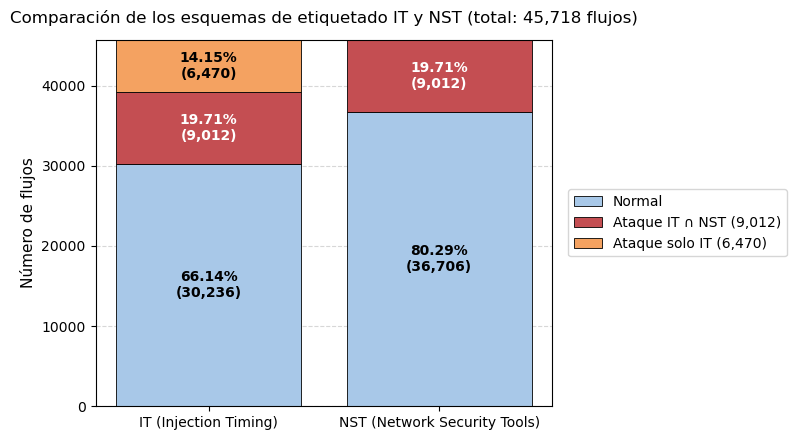

In [12]:
# Columnas de etiquetas
label_cols = [c for c in df.columns if 'label' in c.lower()]
print(f"Columnas de etiquetas: {label_cols}")
print()
for col in label_cols:
    print(f"--- {col} ---")
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(normalize=True, dropna=False) * 100
    dist = pd.DataFrame({'count': counts, 'pct': pct.round(2)})
    print(dist)
    print()

# ===== Verificación de la inclusión NST ⊂ IT =====
n_total = len(df)
n_it_attack  = (df['IT_B_Label'] == 1).sum()
n_nst_attack = (df['NST_B_Label'] == 1).sum()
n_solo_it    = ((df['IT_B_Label'] == 1) & (df['NST_B_Label'] == 0)).sum()
n_ambos      = ((df['IT_B_Label'] == 1) & (df['NST_B_Label'] == 1)).sum()
n_solo_nst   = ((df['IT_B_Label'] == 0) & (df['NST_B_Label'] == 1)).sum()
n_normal     = ((df['IT_B_Label'] == 0) & (df['NST_B_Label'] == 0)).sum()

print(f"Total flujos:                {n_total:,}")
print(f"Ataque IT:                   {n_it_attack:,} ({n_it_attack/n_total*100:.2f} %)")
print(f"Ataque NST:                  {n_nst_attack:,} ({n_nst_attack/n_total*100:.2f} %)")
print(f"Solo IT (no NST):            {n_solo_it:,} ({n_solo_it/n_total*100:.2f} %)")
print(f"Ambos (IT ∩ NST):            {n_ambos:,} ({n_ambos/n_total*100:.2f} %)")
print(f"Solo NST (no IT):            {n_solo_nst:,}  ← debe ser 0 para confirmar NST ⊂ IT")
print(f"Normal en ambos esquemas:    {n_normal:,} ({n_normal/n_total*100:.2f} %)")

# ===== Figura 2: comparación esquemas IT vs NST =====
fig, ax = plt.subplots(figsize=(8, 4.5))

esquemas = ['IT (Injection Timing)', 'NST (Network Security Tools)']
normal  = [n_total - n_it_attack, n_total - n_nst_attack]
solo_it = [n_solo_it, 0]
ambos   = [n_ambos, n_ambos]

c_normal = '#A8C8E8'
c_solo   = '#F4A261'
c_ambos  = '#C44E52'

ax.bar(esquemas, normal, color=c_normal, edgecolor='black', linewidth=0.6, label='Normal')
ax.bar(esquemas, ambos,  bottom=normal, color=c_ambos, edgecolor='black', linewidth=0.6,
       label=f'Ataque IT ∩ NST ({n_ambos:,})')
ax.bar(esquemas, solo_it, bottom=[n + a for n, a in zip(normal, ambos)],
       color=c_solo, edgecolor='black', linewidth=0.6,
       label=f'Ataque solo IT ({n_solo_it:,})')

for i, (n, a, s) in enumerate(zip(normal, ambos, solo_it)):
    ax.text(i, n/2, f'{n/n_total*100:.2f}%\n({n:,})', ha='center', va='center',
            fontsize=10, fontweight='bold')
    if a > 0:
        ax.text(i, n + a/2, f'{a/n_total*100:.2f}%\n({a:,})', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    if s > 0:
        ax.text(i, n + a + s/2, f'{s/n_total*100:.2f}%\n({s:,})', ha='center', va='center',
                fontsize=10, fontweight='bold')

ax.set_ylabel('Número de flujos', fontsize=11)
ax.set_title(f'Comparación de los esquemas de etiquetado IT y NST '
             f'(total: {n_total:,} flujos)', fontsize=12, pad=12)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig_5_2_3_etiquetado.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Buscar las columnas IT y NST binarias y multiclase
it_bin = [c for c in label_cols if 'it' in c.lower() and ('b' in c.lower() or 'bin' in c.lower())]
nst_bin = [c for c in label_cols if 'nst' in c.lower() and ('b' in c.lower() or 'bin' in c.lower())]

print(f"Posibles IT binaria: {it_bin}")
print(f"Posibles NST binaria: {nst_bin}")
print()

# Mostrar todas las etiquetas por multiclase
it_multi = [c for c in label_cols if 'it' in c.lower() and 'm' in c.lower() and c not in it_bin]
nst_multi = [c for c in label_cols if 'nst' in c.lower() and 'm' in c.lower() and c not in nst_bin]
print(f"Posibles IT multiclase: {it_multi}")
print(f"Posibles NST multiclase: {nst_multi}")

Posibles IT binaria: ['IT_B_Label', 'IT_M_Label']
Posibles NST binaria: ['NST_B_Label', 'NST_M_Label']

Posibles IT multiclase: []
Posibles NST multiclase: []


In [14]:
# Carga del attack log
df_attacks = pd.read_csv(CSV_ATTACKS)

print(f"Forma del attack log: {df_attacks.shape}")
print(f"Número de instancias de ataque: {len(df_attacks)}")
print()
print("Columnas:")
print(df_attacks.columns.tolist())
print()
print("Primeras 5 filas:")
print(df_attacks.head())

Forma del attack log: (74, 1)
Número de instancias de ataque: 74

Columnas:
['attack;startStamp;endStamp;startTime;endTime;attackerMAC;attackerIP;description']

Primeras 5 filas:
  attack;startStamp;endStamp;startTime;endTime;attackerMAC;attackerIP;description
0  port-scan;1.663.323.340.037.190;1.663.323.357....                             
1  ip-scan;1.663.323.387.256.530;1.663.323.392.23...                             
2  mitm;166.332.342.226.987;1.663.323.460.084.710...                             
3  port-scan;1.663.323.490.117.120;1.663.323.507....                             
4  mitm;1.663.323.537.688.790;1.663.323.575.245.2...                             


In [15]:
# Buscar la columna de tipo de ataque
attack_type_cols = [c for c in df_attacks.columns if any(k in c.lower() for k in ['attack', 'type', 'name'])]
print(f"Posibles columnas de tipo de ataque: {attack_type_cols}")
print()

# Asumiendo que hay una columna principal de tipo
for col in attack_type_cols:
    print(f"--- {col} ---")
    print(df_attacks[col].value_counts())
    print()

Posibles columnas de tipo de ataque: ['attack;startStamp;endStamp;startTime;endTime;attackerMAC;attackerIP;description']

--- attack;startStamp;endStamp;startTime;endTime;attackerMAC;attackerIP;description ---
attack;startStamp;endStamp;startTime;endTime;attackerMAC;attackerIP;description
port-scan;1.663.323.340.037.190;1.663.323.357.237.410;2022-09-16 12:15:40.037197;2022-09-16 12:15:57.237416;02:42:c0:a8:00:29;192.168.0.41;scan-nmap    1
ip-scan;1.663.326.483.235.560;1.663.326.487.224.560;2022-09-16 13:08:03.235563;2022-09-16 13:08:07.224567;02:42:c0:a8:00:29;192.168.0.41;scan-scapy     1
ip-scan;1.663.326.415.173.670;1.663.326.419.266.580;2022-09-16 13:06:55.173679;2022-09-16 13:06:59.266583;02:42:c0:a8:00:29;192.168.0.41;scan-scapy     1
ddos;1.663.326.324.101.530;166.332.638.516.259;2022-09-16 13:05:24.101532;2022-09-16 13:06:25.162590;02:42:c0:a8:00:29;192.168.0.41;ddos                1
port-scan;1.663.326.274.645.370;1.663.326.289.082.630;2022-09-16 13:04:34.645374;2022-09-16 13

In [11]:
# Verificar desfase horario entre dataset y attack log
print("=== DATASET (columna 'start') ===")
print(f"Primer flujo:  {pd.to_datetime(df['start'].min(), unit='s')}  UTC")
print(f"Último flujo:  {pd.to_datetime(df['start'].max(), unit='s')}  UTC")
print()

print("=== ATTACK LOG (columna 'startStamp') ===")
print(f"Primer ataque: {pd.to_datetime(df_attacks['startStamp'].min(), unit='s')}  UTC")
print(f"Último ataque: {pd.to_datetime(df_attacks['endStamp'].max(), unit='s')}  UTC")
print()

# Cálculos clave
t_dataset_inicio = df['start'].min()
t_ataque_primero = df_attacks['startStamp'].min()
t_dataset_fin    = df['start'].max()
t_ataque_ultimo  = df_attacks['endStamp'].max()

print("=== DURACIONES EN SEGUNDOS (timestamps Unix, sin husos horarios) ===")
print(f"Inicio dataset:       {t_dataset_inicio:.0f}")
print(f"Primer ataque:        {t_ataque_primero:.0f}")
print(f"Último ataque:        {t_ataque_ultimo:.0f}")
print(f"Fin dataset:          {t_dataset_fin:.0f}")
print()

print("=== INTERVALOS ===")
print(f"Ventana normal inicial (inicio dataset -> primer ataque):")
print(f"   {(t_ataque_primero - t_dataset_inicio):.0f} segundos = {(t_ataque_primero - t_dataset_inicio)/60:.2f} minutos")
print()
print(f"Ventana de ataques (primer ataque -> último ataque):")
print(f"   {(t_ataque_ultimo - t_ataque_primero):.0f} segundos = {(t_ataque_ultimo - t_ataque_primero)/60:.2f} minutos")
print()
print(f"Duración total dataset (inicio -> fin):")
print(f"   {(t_dataset_fin - t_dataset_inicio):.0f} segundos = {(t_dataset_fin - t_dataset_inicio)/60:.2f} minutos")
print()

# Verificar número de ataques por tipo (confirmando tabla de ataques)
print("=== ATAQUES POR TIPO (Tabla VII del paper) ===")
print(df_attacks['attack'].value_counts())
print(f"Total instancias: {len(df_attacks)}")
print()

# Duración media de cada tipo de ataque
df_attacks['dur_s'] = df_attacks['endStamp'] - df_attacks['startStamp']
print("=== DURACIÓN MEDIA POR TIPO DE ATAQUE (segundos) ===")
print(df_attacks.groupby('attack')['dur_s'].agg(['count', 'mean', 'sum']).round(2))

=== DATASET (columna 'start') ===
Primer flujo:  2022-09-16 09:14:39.510337114  UTC
Último flujo:  2022-09-16 11:34:22.044183969  UTC

=== ATTACK LOG (columna 'startStamp') ===


KeyError: 'startStamp'

Total flujos: 45,718
Flujos con al menos un valor nulo: 4,358 (9.53%)

=== NULOS POR PROTOCOLO ===
             total  con_nulos  pct_con_nulos
protocol                                    
IPV4-TCP   43984.0     2624.0       5.965806
ARP         1552.0     1552.0     100.000000
IPV4-ICMP    162.0      162.0     100.000000
IPV4-UDP      10.0       10.0     100.000000
IPV6          10.0       10.0     100.000000


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_19952\3280245551.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulos_por_proto = df.groupby('protocol').apply(


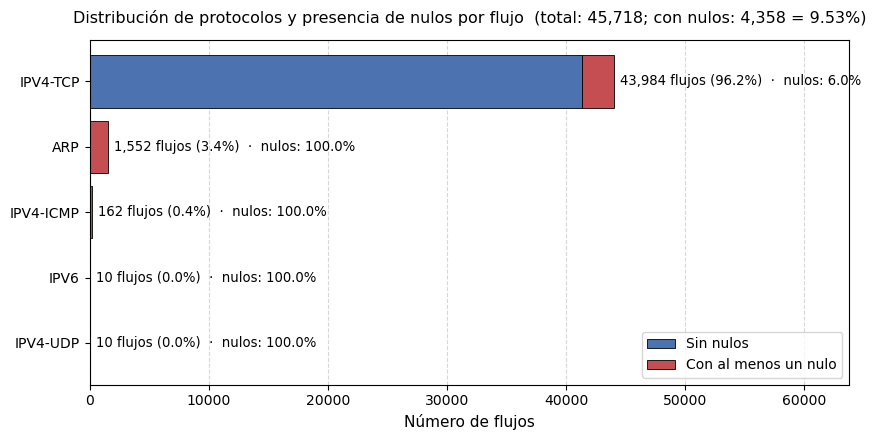

In [16]:
# Nulos a nivel de fila
nulos_por_fila = df.isnull().any(axis=1)
n_con_nulos = nulos_por_fila.sum()
pct_con_nulos = 100 * n_con_nulos / len(df)
print(f"Total flujos: {len(df):,}")
print(f"Flujos con al menos un valor nulo: {n_con_nulos:,} ({pct_con_nulos:.2f}%)")
print()

# Nulos por protocolo
print("=== NULOS POR PROTOCOLO ===")
nulos_por_proto = df.groupby('protocol').apply(
    lambda g: pd.Series({
        'total': len(g),
        'con_nulos': g.isnull().any(axis=1).sum(),
        'pct_con_nulos': 100 * g.isnull().any(axis=1).mean()
    })
).sort_values('total', ascending=False)
print(nulos_por_proto)

# ===== Figura 3: distribución de protocolos y nulos =====
nulos_por_proto_plot = nulos_por_proto.sort_values('total', ascending=True)
protos    = nulos_por_proto_plot.index.tolist()
totales   = nulos_por_proto_plot['total'].astype(int).values
con_nulos = nulos_por_proto_plot['con_nulos'].astype(int).values
sin_nulos = totales - con_nulos
pct_nulos = nulos_por_proto_plot['pct_con_nulos'].values

fig, ax = plt.subplots(figsize=(9, 4.5))
c_sin = '#4C72B0'
c_con = '#C44E52'

ax.barh(protos, sin_nulos, color=c_sin, edgecolor='black', linewidth=0.6,
        label='Sin nulos')
ax.barh(protos, con_nulos, left=sin_nulos, color=c_con, edgecolor='black', linewidth=0.6,
        label='Con al menos un nulo')

xmax = totales.max()
for i, (proto, tot, pn) in enumerate(zip(protos, totales, pct_nulos)):
    pct_d = 100 * tot / totales.sum()
    ax.text(tot + xmax*0.012, i,
            f'{tot:,} flujos ({pct_d:.1f}%)  ·  nulos: {pn:.1f}%',
            va='center', fontsize=9.5)

ax.set_xlabel('Número de flujos', fontsize=11)
ax.set_title(f'Distribución de protocolos y presencia de nulos por flujo  '
             f'(total: {len(df):,}; con nulos: {n_con_nulos:,} = {pct_con_nulos:.2f}%)',
             fontsize=11.5, pad=12)
ax.set_xlim(0, xmax * 1.45)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig_5_3_1_protocolos_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Identificar features TCP típicas
tcp_features = ['sAckRate', 'rAckRate', 'sSynRate', 'rSynRate',
                'sWinTCP', 'rWinTCP', 'sAckDelayAvg', 'rAckDelayAvg',
                'sAckDelayMax', 'rAckDelayMax', 'sttl', 'rttl']

# Para cada protocolo no-TCP, ver porcentaje de nulos en esas columnas
no_tcp = df[df['protocol'] != 'IPV4-TCP']
tcp_rows = df[df['protocol'] == 'IPV4-TCP']

print(f"Flujos no-TCP: {len(no_tcp):,}")
print(f"Flujos TCP:    {len(tcp_rows):,}")
print()

print("=== % DE NULOS EN FEATURES TCP PARA FLUJOS NO-TCP ===")
for col in tcp_features:
    pct = 100 * no_tcp[col].isnull().mean()
    print(f"  {col:20s}: {pct:6.2f}% nulos")

print()
print("=== % DE NULOS EN FEATURES TCP PARA FLUJOS TCP ===")
for col in tcp_features:
    pct = 100 * tcp_rows[col].isnull().mean()
    print(f"  {col:20s}: {pct:6.2f}% nulos")

Flujos no-TCP: 1,734
Flujos TCP:    43,984

=== % DE NULOS EN FEATURES TCP PARA FLUJOS NO-TCP ===
  sAckRate            : 100.00% nulos
  rAckRate            : 100.00% nulos
  sSynRate            : 100.00% nulos
  rSynRate            : 100.00% nulos
  sWinTCP             : 100.00% nulos
  rWinTCP             : 100.00% nulos
  sAckDelayAvg        : 100.00% nulos
  rAckDelayAvg        : 100.00% nulos
  sAckDelayMax        : 100.00% nulos
  rAckDelayMax        : 100.00% nulos
  sttl                : 100.00% nulos
  rttl                : 100.00% nulos

=== % DE NULOS EN FEATURES TCP PARA FLUJOS TCP ===
  sAckRate            :   0.28% nulos
  rAckRate            :   0.00% nulos
  sSynRate            :   0.28% nulos
  rSynRate            :   0.00% nulos
  sWinTCP             :   0.28% nulos
  rWinTCP             :   0.00% nulos
  sAckDelayAvg        :   1.21% nulos
  rAckDelayAvg        :   3.50% nulos
  sAckDelayMax        :   1.21% nulos
  rAckDelayMax        :   3.50% nulos
  sttl        

In [13]:
# Flujos TCP con nulos residuales
tcp_rows = df[df['protocol'] == 'IPV4-TCP']
tcp_con_nulos = tcp_rows[tcp_rows.isnull().any(axis=1)]

print(f"Flujos TCP totales:           {len(tcp_rows):,}")
print(f"Flujos TCP con nulos:         {len(tcp_con_nulos):,}")
print(f"% flujos TCP con nulos:       {100*len(tcp_con_nulos)/len(tcp_rows):.2f}%")
print()

# En qué columnas aparecen los nulos residuales TCP
print("=== COLUMNAS CON NULOS EN FLUJOS TCP ===")
nulos_por_col = tcp_rows.isnull().sum()
nulos_por_col = nulos_por_col[nulos_por_col > 0].sort_values(ascending=False)
print(nulos_por_col)
print()

# Qué ataques generan esos nulos TCP
print("=== TIPO DE ATAQUE DE LOS FLUJOS TCP CON NULOS (IT_M_Label) ===")
print(tcp_con_nulos['IT_M_Label'].value_counts())
print()
print("=== % sobre el total de TCP con nulos ===")
print(tcp_con_nulos['IT_M_Label'].value_counts(normalize=True).round(4) * 100)

Flujos TCP totales:           43,984
Flujos TCP con nulos:         2,624
% flujos TCP con nulos:       5.97%

=== COLUMNAS CON NULOS EN FLUJOS TCP ===
rAckDelayAvg       1541
rAckDelayMin       1541
rAckDelayMax       1541
sInterPacketAvg    1010
sAckDelayAvg        534
sAckDelayMin        534
sAckDelayMax        534
rInterPacketAvg     207
sAckRate            124
sFragmentRate       124
sWinTCP             124
sRstRate            124
sSynRate            124
sPshRate            124
sFinRate            124
sUrgRate            124
sBytesMax           124
sBytesMin           124
sttl                124
sBytesAvg           124
sPayloadAvg         124
sPayloadMax         124
sPayloadMin         124
rAckRate              1
rWinTCP               1
rBytesMin             1
rBytesAvg             1
rFragmentRate         1
rPayloadMax           1
rRstRate              1
rttl                  1
rPayloadMin           1
rSynRate              1
rPshRate              1
rPayloadAvg           1
rFinRate 

Total flujos no-TCP: 1,734

=== DISTRIBUCIÓN DE ATAQUES EN FLUJOS NO-TCP (IT_B_Label) ===
IT_B_Label
1    1540
0     194
Name: count, dtype: int64

=== POR TIPO (IT_M_Label) ===
IT_M_Label
mitm         532
replay       437
port-scan    365
Normal       194
ip-scan      194
ddos          12
Name: count, dtype: int64

=== ¿CUÁNTOS ATAQUES SE PIERDEN AL DESCARTAR NO-TCP? ===
Ataques totales (IT):        15,482
Ataques en flujos no-TCP:    1,540  (9.95%)
Ataques en flujos TCP:       13,942  (90.05%)


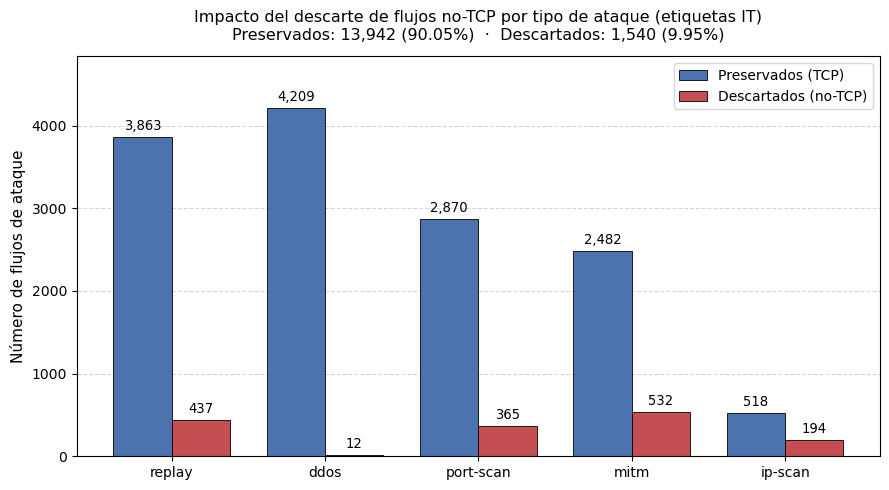

In [17]:
# Flujos no-TCP y su label IT
no_tcp = df[df['protocol'] != 'IPV4-TCP']
tcp_rows = df[df['protocol'] == 'IPV4-TCP']
print(f"Total flujos no-TCP: {len(no_tcp):,}")
print()
print("=== DISTRIBUCIÓN DE ATAQUES EN FLUJOS NO-TCP (IT_B_Label) ===")
print(no_tcp['IT_B_Label'].value_counts())
print()
print("=== POR TIPO (IT_M_Label) ===")
print(no_tcp['IT_M_Label'].value_counts())
print()

# Totales globales
ataques_totales_IT = (df['IT_B_Label'] == 1).sum()
ataques_no_tcp     = (no_tcp['IT_B_Label'] == 1).sum()
ataques_tcp        = (tcp_rows['IT_B_Label'] == 1).sum()
print("=== ¿CUÁNTOS ATAQUES SE PIERDEN AL DESCARTAR NO-TCP? ===")
print(f"Ataques totales (IT):        {ataques_totales_IT:,}")
print(f"Ataques en flujos no-TCP:    {ataques_no_tcp:,}  ({100*ataques_no_tcp/ataques_totales_IT:.2f}%)")
print(f"Ataques en flujos TCP:       {ataques_tcp:,}  ({100*ataques_tcp/ataques_totales_IT:.2f}%)")

# ===== Figura 5: ataques preservados vs descartados por tipo =====
ataques_solo = df[df['IT_B_Label'] == 1].copy()
preservados = ataques_solo[ataques_solo['protocol'] == 'IPV4-TCP']['IT_M_Label'].value_counts()
descartados = ataques_solo[ataques_solo['protocol'] != 'IPV4-TCP']['IT_M_Label'].value_counts()

tipos = sorted(set(preservados.index) | set(descartados.index),
               key=lambda t: -(preservados.get(t, 0) + descartados.get(t, 0)))
pres_v = [preservados.get(t, 0) for t in tipos]
desc_v = [descartados.get(t, 0) for t in tipos]

x = np.arange(len(tipos))
ancho = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - ancho/2, pres_v, ancho, color='#4C72B0',
            edgecolor='black', linewidth=0.6, label='Preservados (TCP)')
b2 = ax.bar(x + ancho/2, desc_v, ancho, color='#C44E52',
            edgecolor='black', linewidth=0.6, label='Descartados (no-TCP)')

ymax = max(max(pres_v), max(desc_v))
for barras, valores in [(b1, pres_v), (b2, desc_v)]:
    for barra, v in zip(barras, valores):
        if v > 0:
            ax.text(barra.get_x() + barra.get_width()/2, v + ymax*0.012,
                    f'{v:,}', ha='center', va='bottom', fontsize=9.5)

ax.set_xticks(x)
ax.set_xticklabels(tipos)
ax.set_ylabel('Número de flujos de ataque', fontsize=11)
ax.set_title(f'Impacto del descarte de flujos no-TCP por tipo de ataque (etiquetas IT)\n'
             f'Preservados: {ataques_tcp:,} ({100*ataques_tcp/ataques_totales_IT:.2f}%)  ·  '
             f'Descartados: {ataques_no_tcp:,} ({100*ataques_no_tcp/ataques_totales_IT:.2f}%)',
             fontsize=11.5, pad=12)
ax.set_ylim(0, ymax * 1.15)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig_5_3_2_descarte.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Buscar valores negativos en las features numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir columnas de tiempo absoluto, offsets, y las etiquetas binarias
exclude = ['start', 'end', 'startOffset', 'endOffset', 'duration',
           'IT_B_Label', 'NST_B_Label']
feature_cols = [c for c in num_cols if c not in exclude]

print(f"Features numéricas a comprobar: {len(feature_cols)}")
print()

# Buscar valores negativos
negativos = {}
for col in feature_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        negativos[col] = {
            'count': int(n_neg),
            'min_value': float(df[col].min()),
            'ejemplos': df.loc[df[col] < 0, col].head(3).tolist()
        }

if negativos:
    print("=== VALORES NEGATIVOS ENCONTRADOS ===")
    for col, info in negativos.items():
        print(f"  {col}:")
        print(f"    N = {info['count']}")
        print(f"    min = {info['min_value']}")
        print(f"    ejemplos = {info['ejemplos']}")
        # Mostrar el tipo de ataque de esos flujos
        flujos_neg = df[df[col] < 0]
        print(f"    tipos de flujo: {flujos_neg['IT_M_Label'].value_counts().to_dict()}")
        print()
else:
    print("No se encontraron valores negativos en las features de flujo.")

Features numéricas a comprobar: 46

=== VALORES NEGATIVOS ENCONTRADOS ===
  rAckDelayAvg:
    N = 1
    min = -2e-06
    ejemplos = [-2e-06]
    tipos de flujo: {'mitm': 1}



Tras descartar no-TCP: 43,984 flujos
Nulos tras relleno:   0
   Corregidos 1 valores negativos en 'rAckDelayAvg'

=== DATASET LIMPIO ===
Total flujos: 43,984
Columnas:     64

=== DISTRIBUCIÓN DE CLASES EN DATASET LIMPIO (IT) ===
  Normal: 30,042  (68.30%)
  Ataque: 13,942  (31.70%)
  Ratio desbalanceo: 2.15 : 1

=== DISTRIBUCIÓN POR TIPO DE ATAQUE EN DATASET LIMPIO ===
IT_M_Label
Normal       30042
ddos          4209
replay        3863
port-scan     2870
mitm          2482
ip-scan        518
Name: count, dtype: int64



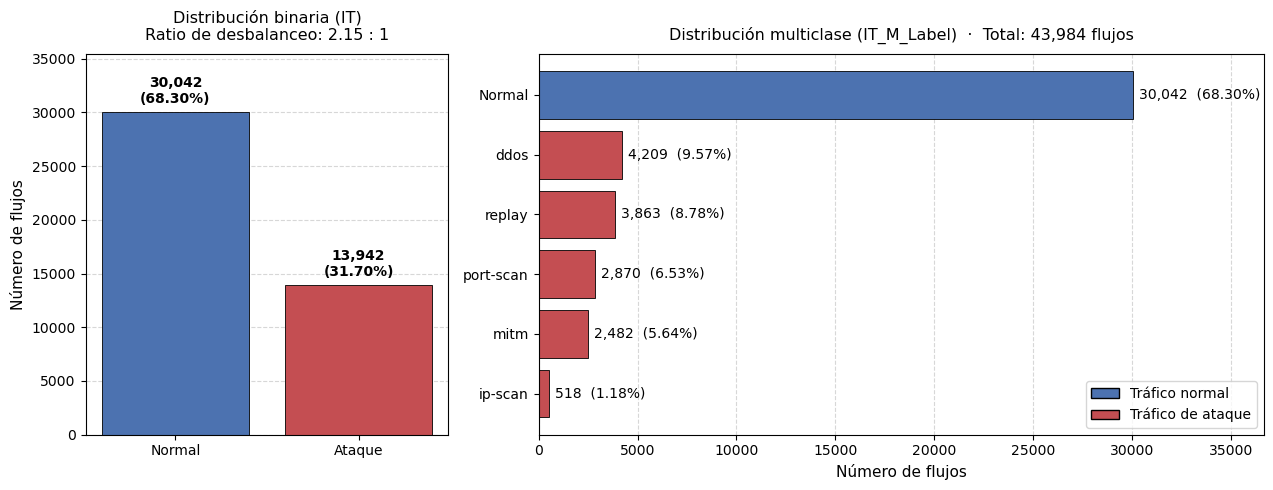

Dataset limpio guardado en: E:\USUARIO\Desktop\Dataset 5\Dataset_clean.parquet


In [20]:
# Aplicar las tres decisiones de limpieza
# 1) Descartar no-TCP
df_clean = df[df['protocol'] == 'IPV4-TCP'].copy()
print(f"Tras descartar no-TCP: {len(df_clean):,} flujos")

# 2) Rellenar nulos con 0
df_clean = df_clean.fillna(0)
print(f"Nulos tras relleno:   {df_clean.isnull().sum().sum()}")

# 3) Corregir negativos: poner a 0 todos los valores negativos en features
for col in feature_cols:
    if col in df_clean.columns:
        n_neg = (df_clean[col] < 0).sum()
        if n_neg > 0:
            df_clean.loc[df_clean[col] < 0, col] = 0
            print(f"   Corregidos {n_neg} valores negativos en '{col}'")
print()

print("=== DATASET LIMPIO ===")
print(f"Total flujos: {len(df_clean):,}")
print(f"Columnas:     {df_clean.shape[1]}")
print()

print("=== DISTRIBUCIÓN DE CLASES EN DATASET LIMPIO (IT) ===")
dist = df_clean['IT_B_Label'].value_counts()
pct  = df_clean['IT_B_Label'].value_counts(normalize=True) * 100
print(f"  Normal: {dist.get(0, 0):,}  ({pct.get(0, 0):.2f}%)")
print(f"  Ataque: {dist.get(1, 0):,}  ({pct.get(1, 0):.2f}%)")
print(f"  Ratio desbalanceo: {dist.get(0, 0) / dist.get(1, 0):.2f} : 1")
print()

print("=== DISTRIBUCIÓN POR TIPO DE ATAQUE EN DATASET LIMPIO ===")
print(df_clean['IT_M_Label'].value_counts())
print()

# ===== Figura 6: distribución de clases (binaria + multiclase) =====
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                gridspec_kw={'width_ratios': [1, 2]})

# --- Subplot 1: distribución binaria ---
n_normal = (df_clean['IT_B_Label'] == 0).sum()
n_ataque = (df_clean['IT_B_Label'] == 1).sum()
total = n_normal + n_ataque
ratio = n_normal / n_ataque

barras1 = ax1.bar(['Normal', 'Ataque'], [n_normal, n_ataque],
                   color=['#4C72B0', '#C44E52'], edgecolor='black', linewidth=0.6)
for barra, n in zip(barras1, [n_normal, n_ataque]):
    p = 100 * n / total
    ax1.text(barra.get_x() + barra.get_width()/2, n + total*0.012,
             f'{n:,}\n({p:.2f}%)', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax1.set_ylabel('Número de flujos', fontsize=11)
ax1.set_title(f'Distribución binaria (IT)\nRatio de desbalanceo: {ratio:.2f} : 1',
              fontsize=11.5, pad=10)
ax1.set_ylim(0, max(n_normal, n_ataque) * 1.18)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# --- Subplot 2: distribución multiclase ---
multi = df_clean['IT_M_Label'].value_counts().sort_values(ascending=True)
multi_pct = (multi / multi.sum() * 100)
colores_multi = ['#4C72B0' if etiqueta == 'Normal' else '#C44E52'
                 for etiqueta in multi.index]

barras2 = ax2.barh(multi.index, multi.values, color=colores_multi,
                    edgecolor='black', linewidth=0.6)
xmax = multi.max()
for barra, n, p in zip(barras2, multi.values, multi_pct.values):
    ax2.text(n + xmax*0.01, barra.get_y() + barra.get_height()/2,
             f'{n:,}  ({p:.2f}%)', va='center', fontsize=10)

ax2.set_xlabel('Número de flujos', fontsize=11)
ax2.set_title(f'Distribución multiclase (IT_M_Label)  ·  Total: {total:,} flujos',
              fontsize=11.5, pad=10)
ax2.set_xlim(0, xmax * 1.22)
ax2.grid(axis='x', linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.legend(handles=[Patch(facecolor='#4C72B0', edgecolor='black', label='Tráfico normal'),
                    Patch(facecolor='#C44E52', edgecolor='black', label='Tráfico de ataque')],
           loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('fig_5_3_3_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar el dataset limpio para las siguientes fases
OUT = DATA_DIR / "Dataset_clean.parquet"
df_clean.to_parquet(OUT)
print(f"Dataset limpio guardado en: {OUT}")

In [17]:
# Cargamos el dataset limpio guardado en la fase anterior
df_clean = pd.read_parquet(DATA_DIR / "Dataset_clean.parquet")
print(f"Dataset limpio cargado: {df_clean.shape}")
print()

# Identificar las 46 features numéricas (excluyendo metadatos y labels)
exclude_cols = [
    'sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs',
    'protocol', 'startDate', 'endDate',
    'start', 'end', 'startOffset', 'endOffset', 'duration',
    'IT_B_Label', 'IT_M_Label', 'NST_B_Label', 'NST_M_Label'
]
feature_cols = [c for c in df_clean.columns if c not in exclude_cols]
print(f"Número de features numéricas: {len(feature_cols)}")
print()
print("Features:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

Dataset limpio cargado: (43984, 64)

Número de features numéricas: 46

Features:
   1. sPackets
   2. rPackets
   3. sBytesSum
   4. rBytesSum
   5. sBytesMax
   6. rBytesMax
   7. sBytesMin
   8. rBytesMin
   9. sBytesAvg
  10. rBytesAvg
  11. sLoad
  12. rLoad
  13. sPayloadSum
  14. rPayloadSum
  15. sPayloadMax
  16. rPayloadMax
  17. sPayloadMin
  18. rPayloadMin
  19. sPayloadAvg
  20. rPayloadAvg
  21. sInterPacketAvg
  22. rInterPacketAvg
  23. sttl
  24. rttl
  25. sAckRate
  26. rAckRate
  27. sUrgRate
  28. rUrgRate
  29. sFinRate
  30. rFinRate
  31. sPshRate
  32. rPshRate
  33. sSynRate
  34. rSynRate
  35. sRstRate
  36. rRstRate
  37. sWinTCP
  38. rWinTCP
  39. sFragmentRate
  40. rFragmentRate
  41. sAckDelayMax
  42. rAckDelayMax
  43. sAckDelayMin
  44. rAckDelayMin
  45. sAckDelayAvg
  46. rAckDelayAvg


In [18]:
# Features clave de la Tabla 5.2 de tu TFG
features_clave = ['sPackets', 'rPackets', 'rLoad', 'sAckRate', 'sSynRate', 'sAckDelayAvg']

# Orden de clases según tu tabla
orden = ['Normal', 'port-scan', 'ip-scan', 'mitm', 'replay', 'ddos']

# Calcular medias por tipo, en el orden deseado
perfil = df_clean.groupby('IT_M_Label')[features_clave].mean()
perfil = perfil.reindex(orden)

# Añadir número de flujos
perfil['n_flujos'] = df_clean['IT_M_Label'].value_counts().reindex(orden)

print("=== VALORES MEDIOS DE FEATURES CLAVE POR TIPO DE ATAQUE ===")
# Formatear con 3 decimales, pero enteros grandes en notación normal
pd.set_option('display.float_format', '{:.3f}'.format)
print(perfil)
print()

# Formateo tabla para tu TFG
print("=== FORMATO PARA LA TABLA 5.X ===")
for clase in orden:
    fila = perfil.loc[clase]
    print(f"{clase:12s} | "
          f"sPackets={fila['sPackets']:.1f} | "
          f"rPackets={fila['rPackets']:.1f} | "
          f"rLoad={fila['rLoad']:,.0f} | "
          f"sAckRate={fila['sAckRate']:.3f} | "
          f"sSynRate={fila['sSynRate']:.3f} | "
          f"sAckDelayAvg={fila['sAckDelayAvg']:.3f} | "
          f"n={int(fila['n_flujos'])}")

=== VALORES MEDIOS DE FEATURES CLAVE POR TIPO DE ATAQUE ===
            sPackets  rPackets        rLoad  sAckRate  sSynRate  sAckDelayAvg  \
IT_M_Label                                                                      
Normal        12.827    15.742   440875.039     1.000     0.000         0.008   
port-scan   2883.422  2885.005  2368448.404     0.931     0.069         0.004   
ip-scan       13.201    16.431   502133.871     1.000     0.000         0.008   
mitm           6.260     7.413 15659050.352     0.955     0.000         0.055   
replay        14.889    21.313   367406.177     1.000     0.000         0.005   
ddos         698.949  1090.660  1574978.855     1.000     0.001         0.008   

            n_flujos  
IT_M_Label            
Normal         30042  
port-scan       2870  
ip-scan          518  
mitm            2482  
replay          3863  
ddos            4209  

=== FORMATO PARA LA TABLA 5.X ===
Normal       | sPackets=12.8 | rPackets=15.7 | rLoad=440,875 | sAckRate=

In [19]:
from scipy.stats import mannwhitneyu

# Muestras: tráfico normal vs tráfico de ataque bajo etiquetado IT
normal_mask = df_clean['IT_B_Label'] == 0
ataque_mask = df_clean['IT_B_Label'] == 1

print(f"N normales: {normal_mask.sum():,}")
print(f"N ataques:  {ataque_mask.sum():,}")
print()

# Ejecutar test para las 46 features
resultados = []
for col in feature_cols:
    normal_vals = df_clean.loc[normal_mask, col]
    ataque_vals = df_clean.loc[ataque_mask, col]
    try:
        stat, pvalue = mannwhitneyu(normal_vals, ataque_vals, alternative='two-sided')
    except ValueError:
        pvalue = np.nan
    resultados.append({
        'feature': col,
        'p_value': pvalue,
        'media_normal': normal_vals.mean(),
        'media_ataque': ataque_vals.mean(),
    })

df_mw = pd.DataFrame(resultados)
print(f"Total features analizadas: {len(df_mw)}")
print()

# Significativas con p < 0.001
umbral = 0.001
n_sig = (df_mw['p_value'] < umbral).sum()
n_no_sig = (df_mw['p_value'] >= umbral).sum()

print(f"Features significativas (p < {umbral}):     {n_sig}")
print(f"Features NO significativas (p >= {umbral}): {n_no_sig}")
print()

print("=== FEATURES NO SIGNIFICATIVAS (p >= 0.001) ===")
no_sig = df_mw[df_mw['p_value'] >= umbral].sort_values('p_value', ascending=False)
print(no_sig.to_string(index=False))
print()

print("=== LAS 7 FEATURES NO SIGNIFICATIVAS, FORMATEADAS ===")
for _, row in no_sig.iterrows():
    print(f"  {row['feature']:20s}  p = {row['p_value']:.4f}  "
          f"(normal: {row['media_normal']:.4f}, ataque: {row['media_ataque']:.4f})")

# Guardar para siguientes celdas
df_mw.to_csv(DATA_DIR / "mannwhitney_results.csv", index=False)
print()
print(f"Resultados guardados en: {DATA_DIR / 'mannwhitney_results.csv'}")

N normales: 30,042
N ataques:  13,942

Total features analizadas: 46

Features significativas (p < 0.001):     39
Features NO significativas (p >= 0.001): 7

=== FEATURES NO SIGNIFICATIVAS (p >= 0.001) ===
      feature  p_value  media_normal  media_ataque
     sUrgRate    1.000         0.000         0.000
     rUrgRate    1.000         0.000         0.000
sFragmentRate    1.000         0.000         0.000
rFragmentRate    1.000         0.000         0.000
      rWinTCP    0.539       504.539       570.747
      sWinTCP    0.403       508.157       490.692
 rAckDelayAvg    0.007         0.023         0.028

=== LAS 7 FEATURES NO SIGNIFICATIVAS, FORMATEADAS ===
  sUrgRate              p = 1.0000  (normal: 0.0000, ataque: 0.0000)
  rUrgRate              p = 1.0000  (normal: 0.0000, ataque: 0.0000)
  sFragmentRate         p = 1.0000  (normal: 0.0000, ataque: 0.0000)
  rFragmentRate         p = 1.0000  (normal: 0.0000, ataque: 0.0000)
  rWinTCP               p = 0.5387  (normal: 504.5386, 

In [20]:
# Las 7 que tú tienes en la Tabla 5.3 de tu TFG
tuyas_no_sig = ['sUrgRate', 'rUrgRate', 'sFragmentRate', 'rFragmentRate',
                'sWinTCP', 'rWinTCP', 'rAckDelayAvg']

# Las que nos ha dado el test
calculadas_no_sig = df_mw[df_mw['p_value'] >= 0.001]['feature'].tolist()

print("=== COMPARACIÓN ===")
print(f"En tu TFG (7):          {sorted(tuyas_no_sig)}")
print(f"Calculadas ahora:       {sorted(calculadas_no_sig)}")
print()

tuyas_set = set(tuyas_no_sig)
calc_set = set(calculadas_no_sig)

solo_tuyas = tuyas_set - calc_set
solo_calc  = calc_set - tuyas_set

if solo_tuyas:
    print(f"En tu TFG pero NO significativas ahora: {solo_tuyas}")
if solo_calc:
    print(f"Nuevas NO significativas que no tenías: {solo_calc}")
if not solo_tuyas and not solo_calc:
    print("COINCIDENCIA PERFECTA")

=== COMPARACIÓN ===
En tu TFG (7):          ['rAckDelayAvg', 'rFragmentRate', 'rUrgRate', 'rWinTCP', 'sFragmentRate', 'sUrgRate', 'sWinTCP']
Calculadas ahora:       ['rAckDelayAvg', 'rFragmentRate', 'rUrgRate', 'rWinTCP', 'sFragmentRate', 'sUrgRate', 'sWinTCP']

COINCIDENCIA PERFECTA


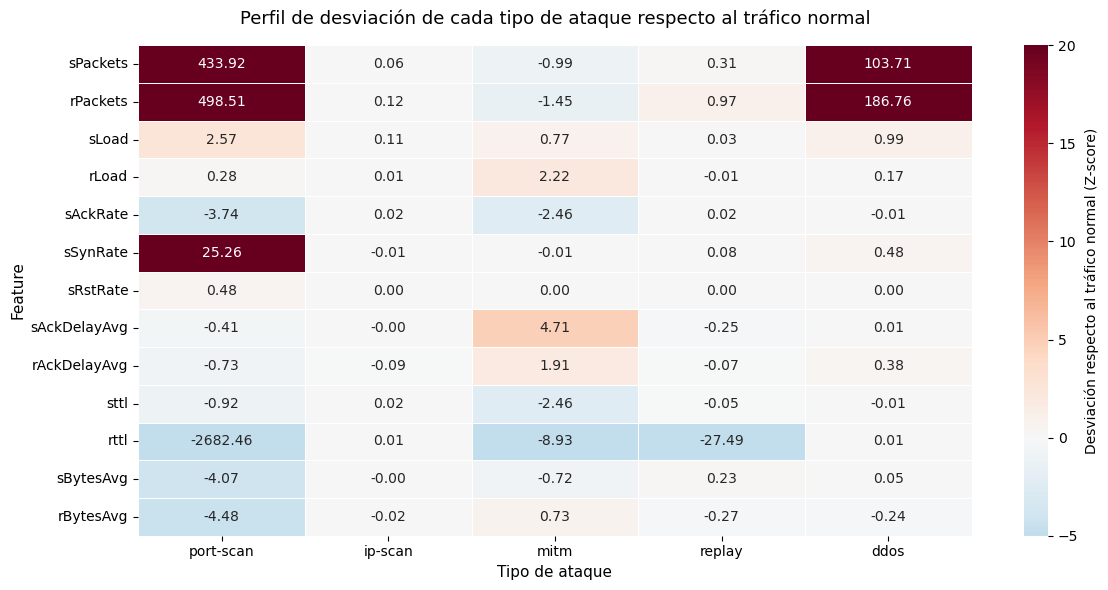


Figura guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_5_1_heatmap_perfiles_ataque.png

=== Z-scores (valores reales, sin clip) ===
IT_M_Label    port-scan  ip-scan   mitm  replay    ddos
sPackets        433.920    0.060 -0.990   0.310 103.710
rPackets        498.510    0.120 -1.450   0.970 186.760
sLoad             2.570    0.110  0.770   0.030   0.990
rLoad             0.280    0.010  2.220  -0.010   0.170
sAckRate         -3.740    0.020 -2.460   0.020  -0.010
sSynRate         25.260   -0.010 -0.010   0.080   0.480
sRstRate          0.480    0.000  0.000   0.000   0.000
sAckDelayAvg     -0.410   -0.000  4.710  -0.250   0.010
rAckDelayAvg     -0.730   -0.090  1.910  -0.070   0.380
sttl             -0.920    0.020 -2.460  -0.050  -0.010
rttl          -2682.460    0.010 -8.930 -27.490   0.010
sBytesAvg        -4.070   -0.000 -0.720   0.230   0.050
rBytesAvg        -4.480   -0.020  0.730  -0.270  -0.240


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Carpeta para guardar figuras
FIGURES_DIR = Path(r"E:\USUARIO\Desktop\Dataset 5") / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Seleccionar features representativas (las más discriminativas de cada dimensión)
features_heatmap = [
    'sPackets', 'rPackets',          # volumen
    'sLoad', 'rLoad',                # carga de red
    'sAckRate', 'sSynRate', 'sRstRate',  # flags TCP
    'sAckDelayAvg', 'rAckDelayAvg',  # temporización
    'sttl', 'rttl',                  # TTL
    'sBytesAvg', 'rBytesAvg',        # tamaños medios
]

# Calcular media y desviación estándar sobre el tráfico NORMAL (referencia)
normal_mask = df_clean['IT_B_Label'] == 0
mu    = df_clean.loc[normal_mask, features_heatmap].mean()
sigma = df_clean.loc[normal_mask, features_heatmap].std().replace(0, 1)  # evitar div/0

# Z-score de la media de cada tipo de ataque respecto al tráfico normal
orden = ['port-scan', 'ip-scan', 'mitm', 'replay', 'ddos']
medias_por_tipo = df_clean.groupby('IT_M_Label')[features_heatmap].mean()
medias_por_tipo = medias_por_tipo.reindex(orden)

# Z-score: cuantas desviaciones estándar se aleja cada tipo del tráfico normal
z_scores = (medias_por_tipo - mu) / sigma

# Recortar valores extremos para mejor visualización
z_clipped = z_scores.clip(lower=-5, upper=20)

# --- HEATMAP ---
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    z_clipped.T,                      # transpuesto: features en filas, tipos en columnas
    annot=z_scores.T.round(2),        # mostrar valores reales (sin clip) en las celdas
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Desviación respecto al tráfico normal (Z-score)'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Perfil de desviación de cada tipo de ataque respecto al tráfico normal',
             fontsize=13, pad=15)
ax.set_xlabel('Tipo de ataque', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar
out_png = FIGURES_DIR / "fig_5_1_heatmap_perfiles_ataque.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigura guardada en: {out_png}")
print(f"\n=== Z-scores (valores reales, sin clip) ===")
print(z_scores.T.round(2))

In [22]:
# Features que se eliminan por no ser significativas (Tabla 5.5)
no_significativas = ['sUrgRate', 'rUrgRate', 'sFragmentRate', 'rFragmentRate',
                     'sWinTCP', 'rWinTCP', 'rAckDelayAvg']

# Features tras paso 1 (Mann-Whitney)
features_paso1 = [c for c in feature_cols if c not in no_significativas]
print(f"Features tras paso 1 (Mann-Whitney): {len(features_paso1)}")
print()

# Calcular matriz de correlación de Pearson
corr = df_clean[features_paso1].corr(method='pearson').abs()

# Identificar pares con |r| > 0.95 (sin duplicar: solo triángulo superior)
import numpy as np
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_upper = corr.where(mask)

pares = []
for col in corr_upper.columns:
    for idx in corr_upper.index:
        valor = corr_upper.loc[idx, col]
        if pd.notna(valor) and valor > 0.95:
            pares.append({
                'feature_A': idx,
                'feature_B': col,
                'r_abs': round(float(valor), 4)
            })

df_pares = pd.DataFrame(pares).sort_values('r_abs', ascending=False).reset_index(drop=True)
print(f"=== PARES CON |r| > 0,95: {len(df_pares)} ===")
print(df_pares.to_string(index=False))

Features tras paso 1 (Mann-Whitney): 39

=== PARES CON |r| > 0,95: 18 ===
  feature_A   feature_B  r_abs
sPayloadSum rPayloadSum  1.000
   rSynRate    sRstRate  1.000
   rAckRate    rSynRate  1.000
   rAckRate    sRstRate  0.999
sPayloadAvg    sPshRate  0.998
   sSynRate    rRstRate  0.996
       rttl    rAckRate  0.996
       rttl    sRstRate  0.994
       rttl    rSynRate  0.994
   rPackets   rBytesSum  0.990
rPayloadAvg    rPshRate  0.990
   sFinRate    rFinRate  0.989
   sPackets   sBytesSum  0.986
   rPackets   sBytesSum  0.985
   sPackets    rPackets  0.975
  sBytesSum   rBytesSum  0.972
  rBytesMax rPayloadMax  0.970
  sBytesMin sPayloadAvg  0.950


In [23]:
# Para cada feature del paso 1, calcular diferencia porcentual de medias
normal_mask = df_clean['IT_B_Label'] == 0
ataque_mask = df_clean['IT_B_Label'] == 1

diferencias = []
for col in features_paso1:
    mu_n = df_clean.loc[normal_mask, col].mean()
    mu_a = df_clean.loc[ataque_mask, col].mean()
    # Diferencia porcentual (protegiendo contra división por cero)
    denom = max(abs(mu_n), 1e-9)
    dif_pct = 100 * abs(mu_a - mu_n) / denom
    diferencias.append({
        'feature': col,
        'mu_normal': round(float(mu_n), 4),
        'mu_ataque': round(float(mu_a), 4),
        'dif_pct': round(float(dif_pct), 2)
    })

df_dif = pd.DataFrame(diferencias).sort_values('dif_pct', ascending=False).reset_index(drop=True)
print("=== DIFERENCIA PORCENTUAL DE MEDIAS (features ordenadas de mayor a menor) ===")
print(df_dif.to_string(index=False))

# Guardar para usar en la eliminación
df_dif.to_csv(DATA_DIR / "diferencias_medias.csv", index=False)

=== DIFERENCIA PORCENTUAL DE MEDIAS (features ordenadas de mayor a menor) ===
        feature  mu_normal   mu_ataque         dif_pct
    rPayloadMin      0.000       0.775 77456605938.890
       sRstRate      0.000       0.100  9955530053.080
       rRstRate      0.000       0.014  1426689140.730
       sFinRate      0.000       0.001    51233682.400
       rFinRate      0.000       0.000    26308994.410
       rSynRate      0.000       0.100      600236.640
       sSynRate      0.000       0.015       65764.240
       sPackets     12.827     810.299        6217.200
       rPackets     15.742     930.985        5814.060
      rBytesSum    938.521   45637.327        4762.680
      sBytesSum    790.227   37857.396        4690.700
   sAckDelayMin      0.000       0.001        2732.950
    sPayloadSum    123.229    2488.456        1919.370
    rPayloadSum    119.942    2299.983        1817.570
   rAckDelayMin      0.000       0.001        1272.990
          rLoad 440875.039 3871158.464    

In [24]:
# Unimos pares correlacionados con la diferencia porcentual de medias
dif_dict = dict(zip(df_dif['feature'], df_dif['dif_pct']))

# Regla: eliminar la feature del par que tenga MENOR dif_pct
eliminadas = set()
for _, row in df_pares.iterrows():
    a, b = row['feature_A'], row['feature_B']
    if a in eliminadas or b in eliminadas:
        continue  # ya se eliminó una del par en otra iteración
    dif_a = dif_dict.get(a, 0)
    dif_b = dif_dict.get(b, 0)
    if dif_a < dif_b:
        eliminadas.add(a)
    else:
        eliminadas.add(b)

print(f"Features eliminadas por correlación: {len(eliminadas)}")
print(sorted(eliminadas))
print()

features_finales = [c for c in features_paso1 if c not in eliminadas]
print(f"=== CONJUNTO FINAL: {len(features_finales)} features ===")
for i, c in enumerate(features_finales, 1):
    print(f"  {i:2d}. {c}")

# Guardar el listado final
import json
with open(DATA_DIR / "features_finales.json", "w") as f:
    json.dump(features_finales, f, indent=2)
print(f"\nConjunto final guardado en: {DATA_DIR / 'features_finales.json'}")

Features eliminadas por correlación: 12
['rAckRate', 'rBytesMax', 'rBytesSum', 'rFinRate', 'rPackets', 'rPayloadSum', 'rPshRate', 'rSynRate', 'rttl', 'sBytesSum', 'sPayloadAvg', 'sSynRate']

=== CONJUNTO FINAL: 27 features ===
   1. sPackets
   2. sBytesMax
   3. sBytesMin
   4. rBytesMin
   5. sBytesAvg
   6. rBytesAvg
   7. sLoad
   8. rLoad
   9. sPayloadSum
  10. sPayloadMax
  11. rPayloadMax
  12. sPayloadMin
  13. rPayloadMin
  14. rPayloadAvg
  15. sInterPacketAvg
  16. rInterPacketAvg
  17. sttl
  18. sAckRate
  19. sFinRate
  20. sPshRate
  21. sRstRate
  22. rRstRate
  23. sAckDelayMax
  24. rAckDelayMax
  25. sAckDelayMin
  26. rAckDelayMin
  27. sAckDelayAvg

Conjunto final guardado en: E:\USUARIO\Desktop\Dataset 5\features_finales.json


In [25]:
# Tu Tabla 5.5 de 28 features declarada
tus_28 = [
    'duration', 'sPackets', 'sBytesMax', 'sBytesMin', 'rBytesMin',
    'sBytesAvg', 'rBytesAvg', 'sLoad', 'rLoad', 'sPayloadSum',
    'sPayloadMax', 'rPayloadMax', 'sPayloadMin', 'rPayloadMin', 'rPayloadAvg',
    'sInterPacketAvg', 'rInterPacketAvg', 'sttl', 'sAckRate', 'sFinRate',
    'sPshRate', 'sRstRate', 'rRstRate', 'sAckDelayMax', 'rAckDelayMax',
    'sAckDelayMin', 'rAckDelayMin', 'sAckDelayAvg'
]

print(f"Tu TFG declara: {len(tus_28)} features")
print(f"Calculadas ahora: {len(features_finales)} features")
print()

tus_set = set(tus_28)
calc_set = set(features_finales)

solo_tuyas = tus_set - calc_set
solo_calc = calc_set - tus_set

print(f"=== EN TU TFG PERO NO EN LAS CALCULADAS ({len(solo_tuyas)}) ===")
print(sorted(solo_tuyas))
print()
print(f"=== CALCULADAS PERO NO EN TU TFG ({len(solo_calc)}) ===")
print(sorted(solo_calc))
print()
print(f"=== EN COMÚN: {len(tus_set & calc_set)} features ===")

Tu TFG declara: 28 features
Calculadas ahora: 27 features

=== EN TU TFG PERO NO EN LAS CALCULADAS (1) ===
['duration']

=== CALCULADAS PERO NO EN TU TFG (0) ===
[]

=== EN COMÚN: 27 features ===


In [26]:
# ¿Qué pinta tiene 'duration'?
print("=== ESTADÍSTICAS DE 'duration' ===")
print(df_clean['duration'].describe())
print()

print("=== 'duration' por clase ===")
print(df_clean.groupby('IT_B_Label')['duration'].agg(['mean', 'std', 'min', 'max']))
print()

# Test de Mann-Whitney para duration
from scipy.stats import mannwhitneyu
normal_dur = df_clean.loc[df_clean['IT_B_Label']==0, 'duration']
ataque_dur = df_clean.loc[df_clean['IT_B_Label']==1, 'duration']
stat, pvalue = mannwhitneyu(normal_dur, ataque_dur, alternative='two-sided')
print(f"Mann-Whitney U para duration: p = {pvalue:.6f}")
print(f"{'Significativa (p<0.001)' if pvalue < 0.001 else 'NO significativa'}")
print()

# Correlación de 'duration' con las 27 features actuales
corr_dur = df_clean[['duration'] + features_finales].corr(method='pearson')['duration'].abs().sort_values(ascending=False)
print("=== Correlaciones |r| de 'duration' con las 27 features finales ===")
print(corr_dur.head(10))

=== ESTADÍSTICAS DE 'duration' ===
count   43984.000
mean        0.374
std         0.179
min         0.000
25%         0.403
50%         0.448
75%         0.498
max         0.500
Name: duration, dtype: float64

=== 'duration' por clase ===
            mean   std   min   max
IT_B_Label                        
0          0.360 0.188 0.000 0.500
1          0.406 0.155 0.000 0.500

Mann-Whitney U para duration: p = 0.000000
Significativa (p<0.001)

=== Correlaciones |r| de 'duration' con las 27 features finales ===
duration          1.000
rAckDelayMax      0.697
sInterPacketAvg   0.400
rInterPacketAvg   0.350
sPayloadMin       0.188
sAckDelayMax      0.185
sPshRate          0.183
sPackets          0.163
sBytesMin         0.153
sPayloadSum       0.144
Name: duration, dtype: float64


In [27]:
# === REPLANTEAMIENTO CON duration INCLUIDA ===

# Features totales = todas las numéricas que no son etiquetas ni metadatos de identificación
exclude_final = [
    'sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs',
    'protocol', 'startDate', 'endDate',
    'start', 'end', 'startOffset', 'endOffset',
    'IT_B_Label', 'IT_M_Label', 'NST_B_Label', 'NST_M_Label'
]
features_v2 = [c for c in df_clean.columns if c not in exclude_final]
print(f"=== Features totales (incluyendo 'duration'): {len(features_v2)} ===")
print()

# Paso 1: Mann-Whitney sobre las 47
from scipy.stats import mannwhitneyu
normal_mask = df_clean['IT_B_Label'] == 0
ataque_mask = df_clean['IT_B_Label'] == 1

resultados_v2 = []
for col in features_v2:
    n, a = df_clean.loc[normal_mask, col], df_clean.loc[ataque_mask, col]
    try:
        _, p = mannwhitneyu(n, a, alternative='two-sided')
    except ValueError:
        p = np.nan
    resultados_v2.append({'feature': col, 'p': p})

df_mw_v2 = pd.DataFrame(resultados_v2)
sig = df_mw_v2[df_mw_v2['p'] < 0.001]['feature'].tolist()
no_sig = df_mw_v2[df_mw_v2['p'] >= 0.001]
print(f"Significativas (p<0.001): {len(sig)}")
print(f"No significativas: {len(no_sig)}")
print()
print("No significativas:")
print(no_sig.to_string(index=False))
print()

# Paso 2: Correlación sobre las 'sig' features
corr = df_clean[sig].corr(method='pearson').abs()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pares = []
for c in corr.columns:
    for i in corr.index:
        if mask[corr.index.get_loc(i), corr.columns.get_loc(c)]:
            v = corr.loc[i, c]
            if v > 0.95:
                pares.append({'A': i, 'B': c, 'r': round(float(v), 4)})
df_pares_v2 = pd.DataFrame(pares).sort_values('r', ascending=False).reset_index(drop=True)
print(f"Pares con |r|>0.95: {len(df_pares_v2)}")
print(df_pares_v2.to_string(index=False))
print()

# Diferencia porcentual de medias
difs = {}
for col in sig:
    mn = df_clean.loc[normal_mask, col].mean()
    ma = df_clean.loc[ataque_mask, col].mean()
    difs[col] = 100 * abs(ma - mn) / max(abs(mn), 1e-9)

# Aplicar la regla de eliminación
eliminadas = set()
for _, row in df_pares_v2.iterrows():
    a, b = row['A'], row['B']
    if a in eliminadas or b in eliminadas:
        continue
    if difs[a] < difs[b]:
        eliminadas.add(a)
    else:
        eliminadas.add(b)

features_finales_v2 = [c for c in sig if c not in eliminadas]
print(f"Features eliminadas por correlación: {len(eliminadas)}")
print(sorted(eliminadas))
print()
print(f"=== CONJUNTO FINAL: {len(features_finales_v2)} features ===")
for i, c in enumerate(features_finales_v2, 1):
    print(f"  {i:2d}. {c}")

# Comparar con tu Tabla 5.5
tus_28 = ['duration', 'sPackets', 'sBytesMax', 'sBytesMin', 'rBytesMin',
          'sBytesAvg', 'rBytesAvg', 'sLoad', 'rLoad', 'sPayloadSum',
          'sPayloadMax', 'rPayloadMax', 'sPayloadMin', 'rPayloadMin', 'rPayloadAvg',
          'sInterPacketAvg', 'rInterPacketAvg', 'sttl', 'sAckRate', 'sFinRate',
          'sPshRate', 'sRstRate', 'rRstRate', 'sAckDelayMax', 'rAckDelayMax',
          'sAckDelayMin', 'rAckDelayMin', 'sAckDelayAvg']

print()
print(f"=== COMPARACIÓN CON TU TFG ===")
print(f"En común: {len(set(tus_28) & set(features_finales_v2))}")
print(f"Solo tuyas: {set(tus_28) - set(features_finales_v2)}")
print(f"Solo calculadas: {set(features_finales_v2) - set(tus_28)}")

# Guardar para siguientes fases
import json
with open(DATA_DIR / "features_finales.json", "w") as f:
    json.dump(features_finales_v2, f, indent=2)
print(f"\nGuardado en: {DATA_DIR / 'features_finales.json'}")

=== Features totales (incluyendo 'duration'): 47 ===

Significativas (p<0.001): 40
No significativas: 7

No significativas:
      feature     p
     sUrgRate 1.000
     rUrgRate 1.000
      sWinTCP 0.403
      rWinTCP 0.539
sFragmentRate 1.000
rFragmentRate 1.000
 rAckDelayAvg 0.007

Pares con |r|>0.95: 18
          A           B     r
sPayloadSum rPayloadSum 1.000
   rSynRate    sRstRate 1.000
   rAckRate    rSynRate 1.000
   rAckRate    sRstRate 0.999
sPayloadAvg    sPshRate 0.998
   sSynRate    rRstRate 0.996
       rttl    rAckRate 0.996
       rttl    sRstRate 0.994
       rttl    rSynRate 0.994
   rPackets   rBytesSum 0.990
rPayloadAvg    rPshRate 0.990
   sFinRate    rFinRate 0.989
   sPackets   sBytesSum 0.986
   rPackets   sBytesSum 0.985
   sPackets    rPackets 0.975
  sBytesSum   rBytesSum 0.972
  rBytesMax rPayloadMax 0.970
  sBytesMin sPayloadAvg 0.950

Features eliminadas por correlación: 12
['rAckRate', 'rBytesMax', 'rBytesSum', 'rFinRate', 'rPackets', 'rPayloadSum', 'rP

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar el conjunto final de 28 features
import json
with open(DATA_DIR / "features_finales.json") as f:
    features_28 = json.load(f)
print(f"Features finales: {len(features_28)}")

# X e y
X = df_clean[features_28]
y = df_clean['IT_B_Label']
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print()

# División 70/30 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print("=== DIVISIÓN SUPERVISADOS (70/30 estratificada) ===")
print(f"Train total:  {len(X_train):,}  ({100*len(X_train)/len(X):.2f}%)")
print(f"Test total:   {len(X_test):,}  ({100*len(X_test)/len(X):.2f}%)")
print()

# Distribución en train
print(f"Train -> Normal: {(y_train==0).sum():,}  ({100*(y_train==0).mean():.2f}%)")
print(f"Train -> Ataque: {(y_train==1).sum():,}  ({100*(y_train==1).mean():.2f}%)")
print()
print(f"Test  -> Normal: {(y_test==0).sum():,}  ({100*(y_test==0).mean():.2f}%)")
print(f"Test  -> Ataque: {(y_test==1).sum():,}  ({100*(y_test==1).mean():.2f}%)")
print()

# Para los no supervisados: solo los flujos normales del train
X_train_normal = X_train[y_train == 0]
print("=== DIVISIÓN NO SUPERVISADOS ===")
print(f"Train normal:     {len(X_train_normal):,}")
print(f"Test (con ambas): {len(X_test):,}")
print()

# Pesos de clase para MLP (scikit-learn 'balanced')
# Fórmula: n_samples / (n_classes * n_samples_class)
n_normal = (y_train == 0).sum()
n_ataque = (y_train == 1).sum()
n_total  = len(y_train)

w_normal = n_total / (2 * n_normal)
w_ataque = n_total / (2 * n_ataque)
print("=== PESOS DE CLASE (balanced) ===")
print(f"Normal (clase 0): {w_normal:.4f}")
print(f"Ataque (clase 1): {w_ataque:.4f}")
print()

# scale_pos_weight para XGBoost
scale_pos = n_normal / n_ataque
print(f"scale_pos_weight XGBoost: {scale_pos:.4f}")

# Normalización con StandardScaler (fit solo en train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verificación rápida de la normalización
print()
print("=== VERIFICACIÓN DE NORMALIZACIÓN ===")
print(f"X_train_scaled - media:     {X_train_scaled.mean():.6f}  (esperado: ~0)")
print(f"X_train_scaled - std:       {X_train_scaled.std():.6f}   (esperado: ~1)")
print(f"X_test_scaled  - media:     {X_test_scaled.mean():.6f}   (debe ser ≈ 0 pero no exactamente)")
print(f"X_test_scaled  - std:       {X_test_scaled.std():.6f}    (debe ser ≈ 1 pero no exactamente)")

# Guardar splits (y_train en el mismo DataFrame, para el análisis por tipo de ataque después)
import numpy as np
np.savez(
    DATA_DIR / "splits.npz",
    X_train=X_train_scaled, X_test=X_test_scaled,
    y_train=y_train.values, y_test=y_test.values
)
# También guardamos las versiones sin escalar (por si luego necesitamos etiquetas multiclase)
y_train_multi = df_clean.loc[X_train.index, 'IT_M_Label'].values
y_test_multi  = df_clean.loc[X_test.index,  'IT_M_Label'].values
np.savez(
    DATA_DIR / "splits_multi.npz",
    y_train_multi=y_train_multi, y_test_multi=y_test_multi
)
print(f"\nSplits guardados en: {DATA_DIR / 'splits.npz'}")
print(f"Labels multiclase en: {DATA_DIR / 'splits_multi.npz'}")

Features finales: 28
Shape X: (43984, 28)
Shape y: (43984,)

=== DIVISIÓN SUPERVISADOS (70/30 estratificada) ===
Train total:  30,788  (70.00%)
Test total:   13,196  (30.00%)

Train -> Normal: 21,029  (68.30%)
Train -> Ataque: 9,759  (31.70%)

Test  -> Normal: 9,013  (68.30%)
Test  -> Ataque: 4,183  (31.70%)

=== DIVISIÓN NO SUPERVISADOS ===
Train normal:     21,029
Test (con ambas): 13,196

=== PESOS DE CLASE (balanced) ===
Normal (clase 0): 0.7320
Ataque (clase 1): 1.5774

scale_pos_weight XGBoost: 2.1548

=== VERIFICACIÓN DE NORMALIZACIÓN ===
X_train_scaled - media:     0.000000  (esperado: ~0)
X_train_scaled - std:       1.000000   (esperado: ~1)
X_test_scaled  - media:     0.008395   (debe ser ≈ 0 pero no exactamente)
X_test_scaled  - std:       0.999033    (debe ser ≈ 1 pero no exactamente)

Splits guardados en: E:\USUARIO\Desktop\Dataset 5\splits.npz
Labels multiclase en: E:\USUARIO\Desktop\Dataset 5\splits_multi.npz


In [30]:
# ============================================================
# BASELINE Z-SCORE
# ============================================================
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import time

# Cargar los splits guardados
with np.load(DATA_DIR / "splits.npz") as npz:
    X_train = npz['X_train']
    X_test  = npz['X_test']
    y_train = npz['y_train']
    y_test  = npz['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print()

# --- PASO 1: Perfil de normalidad sobre el train normal ---
# Los datos ya están estandarizados (media 0, std 1 sobre el train completo),
# pero necesitamos el perfil sobre el train SOLO normal
# OJO: StandardScaler se aplicó sobre el train completo (normal + ataque),
# pero para el baseline Z-score necesitamos media/std de SOLO los normales.
# Recargamos y reescalamos:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import json

with open(DATA_DIR / "features_finales.json") as f:
    features_28 = json.load(f)

X_raw = df_clean[features_28]
y     = df_clean['IT_B_Label']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.30, stratify=y, random_state=42
)

# Solo flujos normales del train
X_train_normal = X_train_raw[y_train_raw == 0]
print(f"Flujos normales en train: {len(X_train_normal):,}")

# Media y std sobre normales del train
mu    = X_train_normal.mean()
sigma = X_train_normal.std().replace(0, 1e-9)  # evitar div/0

# --- PASO 2: Z-score máximo para cada flujo del test ---
z_test = ((X_test_raw - mu).abs() / sigma).max(axis=1).values
print(f"\nEstadísticas del Z-score máximo en test:")
print(f"  min:     {z_test.min():.4f}")
print(f"  mediana: {np.median(z_test):.4f}")
print(f"  max:     {z_test.max():.4f}")

# --- PASO 3: Barrido de umbrales k ---
umbrales = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
t0 = time.time()
resultados_baseline = []
for k in umbrales:
    y_pred = (z_test > k).astype(int)
    prec = precision_score(y_test_raw, y_pred, zero_division=0)
    rec  = recall_score(y_test_raw, y_pred, zero_division=0)
    f1   = f1_score(y_test_raw, y_pred, zero_division=0)
    tp = int(((y_pred == 1) & (y_test_raw == 1)).sum())
    fp = int(((y_pred == 1) & (y_test_raw == 0)).sum())
    fn = int(((y_pred == 0) & (y_test_raw == 1)).sum())
    tn = int(((y_pred == 0) & (y_test_raw == 0)).sum())
    resultados_baseline.append({
        'k': k, 'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1': round(f1, 4), 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'predichos_ataque': int(y_pred.sum())
    })

auc = roc_auc_score(y_test_raw, z_test)
tiempo = time.time() - t0

df_baseline = pd.DataFrame(resultados_baseline)
print(f"\n=== RESULTADOS BASELINE Z-SCORE ===")
print(df_baseline.to_string(index=False))
print(f"\nAUC-ROC (todo el barrido de umbrales): {auc:.4f}")
print(f"Tiempo total: {tiempo:.2f} s")

# Identificar el mejor k
mejor = df_baseline.loc[df_baseline['F1'].idxmax()]
print(f"\n=== MEJOR UMBRAL ===")
print(f"k = {mejor['k']}")
print(f"F1 = {mejor['F1']:.4f}")
print(f"Precision = {mejor['Precision']:.4f}")
print(f"Recall = {mejor['Recall']:.4f}")

# Guardar resultados para el capítulo 6
df_baseline.to_csv(DATA_DIR / "resultados_baseline.csv", index=False)
np.save(DATA_DIR / "baseline_scores.npy", z_test)
print(f"\nGuardado en: {DATA_DIR / 'resultados_baseline.csv'}")

X_train shape: (30788, 28)
X_test shape:  (13196, 28)

Flujos normales en train: 21,029

Estadísticas del Z-score máximo en test:
  min:     0.7422
  mediana: 1.5003
  max:     52000000000.0000

=== RESULTADOS BASELINE Z-SCORE ===
    k  Precision  Recall    F1   TP   FP   FN   TN  predichos_ataque
1.000      0.309   0.961 0.467 4020 9008  163    5             13028
1.500      0.424   0.669 0.519 2799 3800 1384 5213              6599
2.000      0.750   0.511 0.608 2139  713 2044 8300              2852
2.500      0.794   0.489 0.605 2045  531 2138 8482              2576
3.000      0.826   0.469 0.598 1962  414 2221 8599              2376
4.000      0.851   0.443 0.583 1854  324 2329 8689              2178
5.000      0.920   0.398 0.555 1663  144 2520 8869              1807

AUC-ROC (todo el barrido de umbrales): 0.7137
Tiempo total: 0.13 s

=== MEJOR UMBRAL ===
k = 2.0
F1 = 0.6081
Precision = 0.7500
Recall = 0.5114

Guardado en: E:\USUARIO\Desktop\Dataset 5\resultados_baseline.csv
